<a href="https://colab.research.google.com/github/Yenuli0808/AI-Job-Market-Analyzer/blob/main/Notebook/Exploration_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =========== **IMPORT LIBRARIES** ==================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


# ========= **Load DataSet** ===============

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
jobs = pd.read_csv("/content/drive/MyDrive/Individual_Project/AI_JOB_MARKET/job_postings.csv")
skills = pd.read_csv("/content/drive/MyDrive/Individual_Project/AI_JOB_MARKET/job_skills.csv")

print("Datasets loaded successfully ✅")

Datasets loaded successfully ✅


In [4]:
# ==============================
# BASIC INFO
# ==============================

print("Jobs Shape:", jobs.shape)
print("Skills Shape:", skills.shape)

Jobs Shape: (12217, 15)
Skills Shape: (12217, 2)


In [5]:
# Preview datasets
jobs.head()

,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite
3,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:30:55.796572+00,Finished NER,t,t,f,Senior Data Warehouse Developer / Architect,Morph Enterprise,"Harrisburg, PA",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/lead-data-e...,2024-01-21 08:08:58.312124+00,Finished NER,t,t,f,Lead Data Engineer,Dice,"Plano, TX",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite


In [6]:
skills.head()

,job_link,job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,"ETL, Data Integration, Data Transformation, Da..."
3,https://www.linkedin.com/jobs/view/senior-data...,"Data Lakes, Data Bricks, Azure Data Factory Pi..."
4,https://www.linkedin.com/jobs/view/lead-data-e...,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S..."


In [7]:
# Column names
print("Jobs Columns:", jobs.columns)
print("Skills Columns:", skills.columns)

Jobs Columns: Index(['job_link', 'last_processed_time', 'last_status', 'got_summary',
       'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location',
       'first_seen', 'search_city', 'search_country', 'search_position',
       'job_level', 'job_type'],
      dtype='object')
Skills Columns: Index(['job_link', 'job_skills'], dtype='object')


In [8]:
# ==============================
# DATA TYPES & INFO
# ==============================

jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12217 entries, 0 to 12216
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_link             12217 non-null  object
 1   last_processed_time  12217 non-null  object
 2   last_status          12217 non-null  object
 3   got_summary          12217 non-null  object
 4   got_ner              12217 non-null  object
 5   is_being_worked      12217 non-null  object
 6   job_title            12217 non-null  object
 7   company              12217 non-null  object
 8   job_location         12216 non-null  object
 9   first_seen           12217 non-null  object
 10  search_city          12217 non-null  object
 11  search_country       12217 non-null  object
 12  search_position      12217 non-null  object
 13  job_level            12217 non-null  object
 14  job_type             12217 non-null  object
dtypes: object(15)
memory usage: 1.4+ MB


In [9]:
skills.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12217 entries, 0 to 12216
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   job_link    12217 non-null  object
 1   job_skills  12212 non-null  object
dtypes: object(2)
memory usage: 191.0+ KB


In [10]:
# ==============================
# MISSING VALUES
# ==============================

print("Jobs Missing Values:")
print(jobs.isnull().sum())

print("\nSkills Missing Values:")
print(skills.isnull().sum())

Jobs Missing Values:
job_link               0
last_processed_time    0
last_status            0
got_summary            0
got_ner                0
is_being_worked        0
job_title              0
company                0
job_location           1
first_seen             0
search_city            0
search_country         0
search_position        0
job_level              0
job_type               0
dtype: int64

Skills Missing Values:
job_link      0
job_skills    5
dtype: int64


In [11]:
# ==============================
# MERGE DATASETS
# ==============================

df = jobs.merge(skills, on="job_link")

print("Merged Shape:", df.shape)
df.head()

Merged Shape: (12217, 16)


,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite,"Machine Learning, Programming, Python, Scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite,"ETL, Data Integration, Data Transformation, Da..."
3,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:30:55.796572+00,Finished NER,t,t,f,Senior Data Warehouse Developer / Architect,Morph Enterprise,"Harrisburg, PA",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite,"Data Lakes, Data Bricks, Azure Data Factory Pi..."
4,https://www.linkedin.com/jobs/view/lead-data-e...,2024-01-21 08:08:58.312124+00,Finished NER,t,t,f,Lead Data Engineer,Dice,"Plano, TX",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S..."


In [12]:
df["job_skills"].head()

,job_skills
0,"Machine Learning, Programming, Python, Scala, ..."
1,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,"ETL, Data Integration, Data Transformation, Da..."
3,"Data Lakes, Data Bricks, Azure Data Factory Pi..."
4,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S..."


In [13]:
# ==============================
# CLEAN DATA
# ==============================

# Drop duplicates
df = df.drop_duplicates()

# Drop missing values
df = df.dropna()

# Standardize text
df["job_title"] = df["job_title"].str.lower()
df["job_skills"] = df["job_skills"].str.lower()

print("Cleaned Data Shape:", df.shape)

Cleaned Data Shape: (12211, 16)


In [14]:
# Convert string -> List
df["job_skills"] = df["job_skills"].apply(lambda x: x.split(","))

In [15]:
# Remove spaces
df["job_skills"] = df["job_skills"].apply(lambda skills: [s.strip() for s in skills])

In [16]:
# Convert to lowercase
df["job_skills"] = df["job_skills"].apply(lambda skills: [s.lower() for s in skills])

In [17]:
df = df.explode("job_skills")

In [18]:
# Normalize Skills
skill_map = {
    "ml": "machine learning",
    "ai": "artificial intelligence",
    "python programming": "python",
    "sql databases": "sql"
}

def normalize(skill):
    return skill_map.get(skill, skill)

df["job_skills"] = df["job_skills"].apply(normalize)

In [19]:
# Remove empty values
df = df[df["job_skills"] != ""]
df = df.dropna(subset=["job_skills"])

In [20]:
df["job_skills"].head()

,job_skills
0,machine learning
0,programming
0,python
0,scala
0,java


In [21]:
# ==============================
# FILTER DATA ROLES
# ==============================

roles = [
    "data scientist",
    "data analyst",
    "machine learning engineer",
    "ai engineer"
]

df = df[df["job_title"].str.contains('|'.join(roles), na=False)]

print("Filtered Shape:", df.shape)

Filtered Shape: (80148, 16)


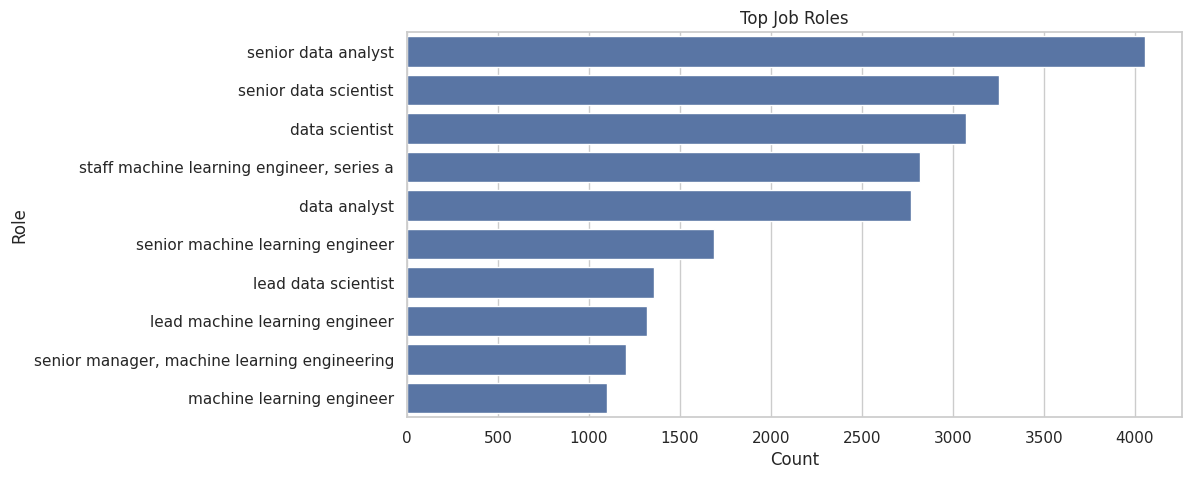

In [22]:
# ==============================
# JOB ROLE DISTRIBUTION
# ==============================

role_counts = df["job_title"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=role_counts.values, y=role_counts.index)
plt.title("Top Job Roles")
plt.xlabel("Count")
plt.ylabel("Role")
plt.show()

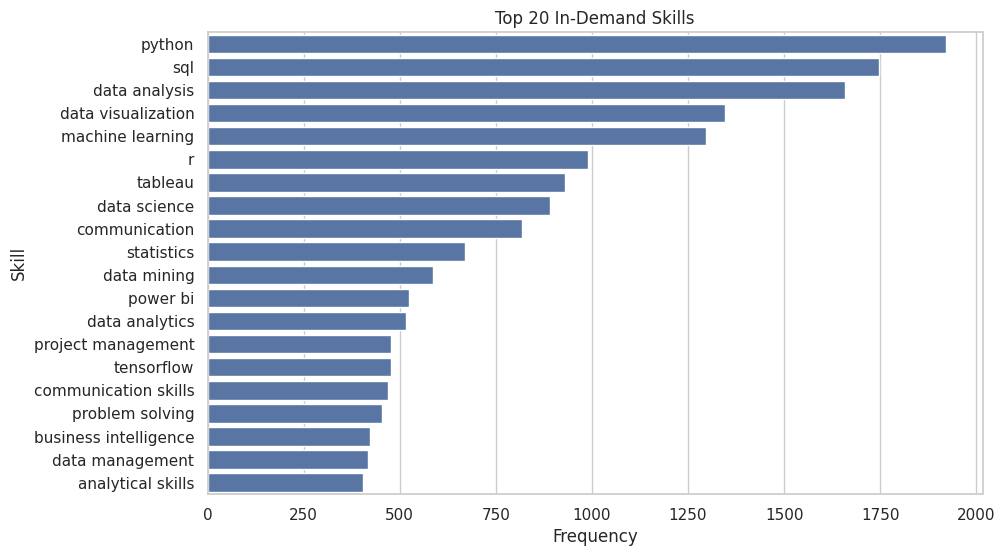

,count
job_skills,
python,1920
sql,1748
data analysis,1659
data visualization,1346
machine learning,1296
r,991
tableau,931
data science,892
communication,819


In [23]:
# ==============================
# TOP SKILLS
# ==============================

top_skills = df["job_skills"].value_counts().head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=top_skills.values, y=top_skills.index)
plt.title("Top 20 In-Demand Skills")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.show()

top_skills

In [24]:
# ==============================
# SKILLS PER ROLE
# ==============================

skills_by_role = df.groupby("job_title")["job_skills"].apply(lambda x: x.str.split(', ').explode().value_counts().head(5))

skills_by_role

job_title                                                                   
#23-078 senior research & data analyst                   data cleaning          2
                                                         data extraction        2
                                                         data integrity         2
                                                         data analysis          2
                                                         data interpretation    2
                                                                               ..
🌟 expression of interest - data scientist opportunities  data analytics         1
                                                         machine learning       1
                                                         predictive modeling    1
                                                         data visualization     1
                                                         data pipelines         1
Name: job_skills, Length: 6430, dtype: int64

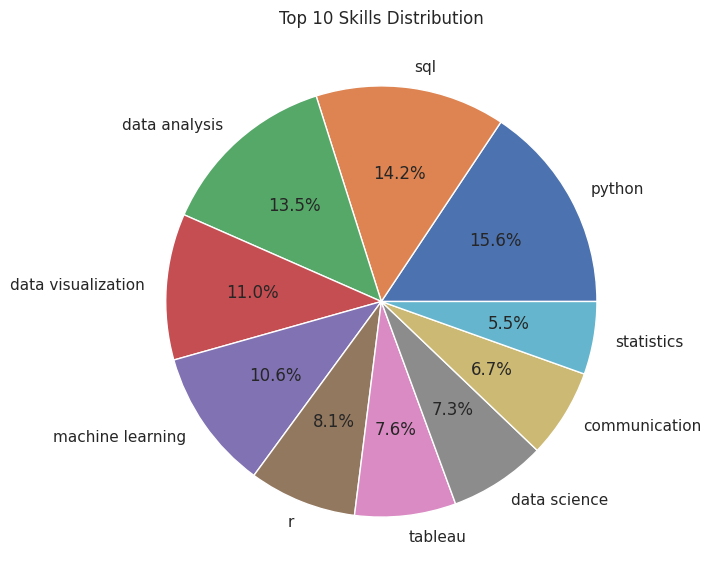

In [25]:
# ==============================
# PIE CHART
# ==============================

top10 = df["job_skills"].value_counts().head(10)

plt.figure(figsize=(7,7))
plt.pie(top10.values, labels=top10.index, autopct='%1.1f%%')
plt.title("Top 10 Skills Distribution")
plt.show()

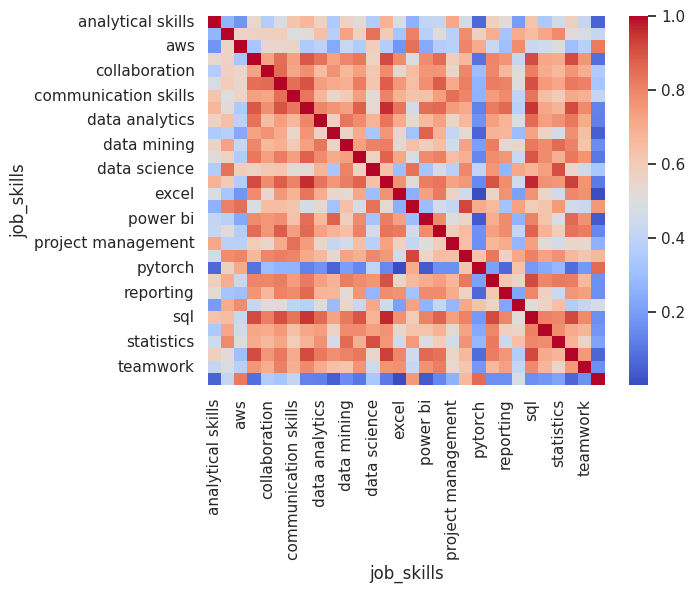

In [26]:
# ==============================
# SKILL CO-OCCURRENCE (ADVANCED)
# ==============================

top_skills = df["job_skills"].value_counts().head(30).index

filtered_df = df[df["job_skills"].isin(top_skills)]

pivot = pd.crosstab(filtered_df["job_title"], filtered_df["job_skills"])
correlation = pivot.corr()

sns.heatmap(correlation, cmap="coolwarm")
plt.show()

In [27]:
# ==============================
# INSIGHTS
# ==============================

print("Top 5 Skills:")
print(df["job_skills"].value_counts().head(5))

print("\nTop Roles:")
print(df["job_title"].value_counts().head(5))

Top 5 Skills:
job_skills
python                1920
sql                   1748
data analysis         1659
data visualization    1346
machine learning      1296
Name: count, dtype: int64

Top Roles:
job_title
senior data analyst                          4057
senior data scientist                        3251
data scientist                               3070
staff machine learning engineer, series a    2817
data analyst                                 2768
Name: count, dtype: int64


In [29]:
# ==============================
# SAVE CLEAN DATA
# ==============================

df.to_csv("/content/drive/MyDrive/Individual_Project/AI_JOB_MARKET/cleaned_data.csv", index=False)

print("Cleaned data saved successfully ✅")

Cleaned data saved successfully ✅
